# Data Exploration and Feature Extraction

The goal of this notebook is to explore the audio dataset and extract meaningful features for language classification.

We work with speech recordings in three languages:
- Polish (pl)
- Portuguese (pt)
- English (en)

In this step, we focus on:
- loading audio files
- analyzing their properties
- extracting MFCC features (Mel-Frequency Cepstral Coefficients)

## 1. Importing Libraries

In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

## 2. Loading Audio Data

We start by selecting a sample audio file from the dataset and loading it using the `librosa` library.

All audio is resampled to 16 kHz for consistency.

In [15]:
folder = "../data/raw/pl"

files = os.listdir(folder)
file_path = os.path.join(folder, files[0])

print("Selected file:", file_path)

Selected file: ../data/raw/pl\common_voice_pl_20547774.mp3


In [16]:
audio, sr = librosa.load(file_path, sr=16000)

print("Sample rate:", sr)
print("Duration (seconds):", len(audio) / sr)

Sample rate: 16000
Duration (seconds): 6.864


## 3. Audio Preprocessing

To ensure consistent input for the model, each audio sample is trimmed to a fixed length of 3 seconds.

Instead of always taking the beginning of the recording, a random fragment is selected. This approach:
- reduces bias (e.g., silence at the beginning),
- improves model generalization,
- ensures more representative audio segments.

This preprocessing step guarantees that all inputs have the same length, which is required for CNN-based models.

In [17]:
import random

start = random.randint(0, len(audio) - 3 * sr)
audio = audio[start:start + 3 * sr]

## 4. MFCC Feature Extraction

We extract MFCC (Mel-Frequency Cepstral Coefficients), which are widely used in speech recognition.

MFCCs capture the spectral characteristics of audio signals and are effective for distinguishing between languages.

In [18]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

# normalize MFCC features
mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)
print("MFCC shape:", mfcc.shape)

MFCC shape: (40, 94)


## 5. Feature Comparison Across Languages

In this section, we compare MFCC and Mel Spectrogram representations for different languages:
- Polish (pl)
- Portuguese (pt)
- English (en)

This helps to visually understand differences in speech characteristics across languages.

In [21]:
import random

def plot_audio_features(folder, title):
    files = os.listdir(folder)
    file_path = os.path.join(folder, random.choice(files))

    audio, sr = librosa.load(file_path, sr=16000)

    # random slice
    if len(audio) > 3 * sr:
        start = random.randint(0, len(audio) - 3 * sr)
        audio = audio[start:start + 3 * sr]

    # MFCC
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)

    # Mel Spectrogram
    spec = librosa.feature.melspectrogram(y=audio, sr=sr)
    spec_db = librosa.power_to_db(spec, ref=np.max)

    # PLOT
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    librosa.display.specshow(mfcc, x_axis='time', cmap='coolwarm', ax=ax[0])
    ax[0].set_title(f'{title} - MFCC')

    librosa.display.specshow(spec_db, x_axis='time', y_axis='mel', cmap='viridis', ax=ax[1])
    ax[1].set_title(f'{title} - Mel Spectrogram')

    plt.tight_layout()
    plt.show()

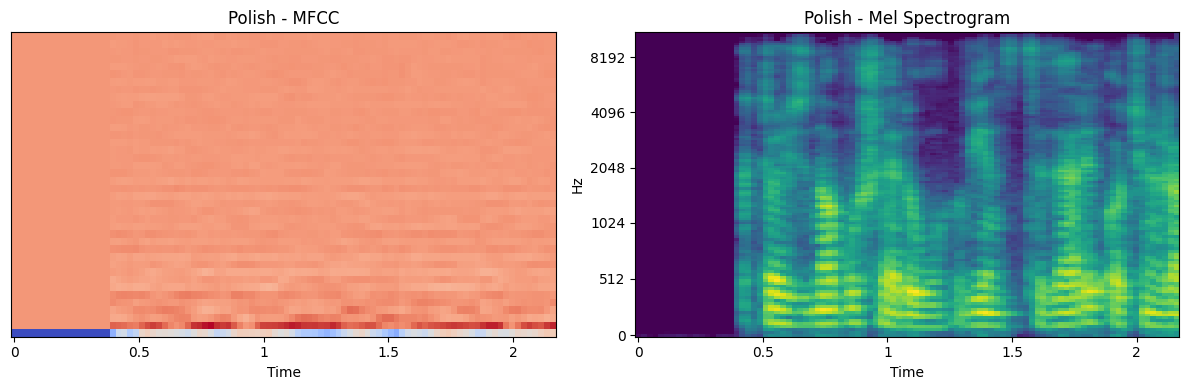

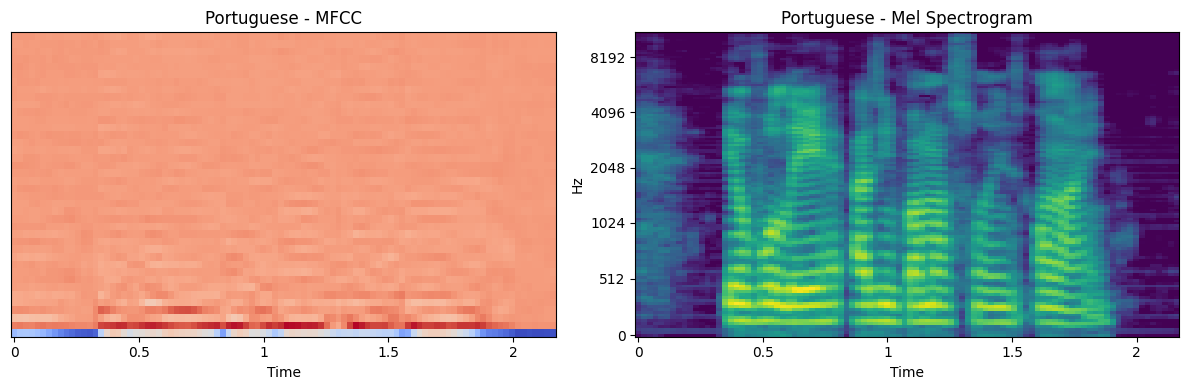

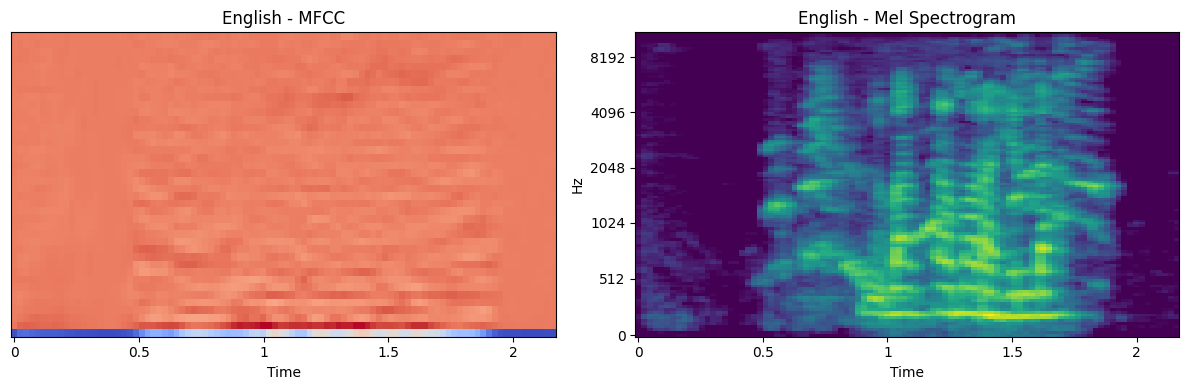

In [23]:
plot_audio_features("../data/raw/pl", "Polish")
plot_audio_features("../data/raw/pt", "Portuguese")
plot_audio_features("../data/raw/en", "English")

## 5. Observations

Based on the visual analysis of MFCC and Mel Spectrogram representations across the three languages (Polish, Portuguese, and English), several observations can be made:

### MFCC Representation
- MFCC features appear relatively smooth and less visually detailed.
- Most of the variation is concentrated in the lower coefficients, while higher coefficients remain relatively uniform.
- Although MFCCs are less interpretable visually, they still encode important spectral characteristics of speech.
- Differences between languages are not easily distinguishable by eye in MFCC space.

### Mel Spectrogram Representation
- Mel Spectrograms provide a much richer and more structured representation of the audio signal.
- Clear patterns can be observed in the lower frequency bands, where most speech energy is concentrated.
- Temporal structures (speech rhythm and phoneme transitions) are more visible.
- Differences between languages are more noticeable, especially in terms of frequency distribution and intensity patterns.

### Cross-Language Differences
- Each language exhibits slightly different spectral patterns and temporal dynamics.
- Portuguese and English show more variation in mid-frequency ranges, while Polish appears slightly more structured in lower frequencies.
- These differences suggest that the model can learn discriminative features for language classification.

### Conclusion
- While MFCC features are compact and widely used, they are less informative visually.
- Mel Spectrograms provide a richer and more expressive representation of speech signals.
- Based on these observations, **Mel Spectrograms are chosen as the primary input representation for the CNN model**, as they are better suited for capturing language-specific characteristics.